# Day 1 — Unsupervised Learning & K-Means

    The dataset that will be used is the Mall Customers dataset that records the customers' ages, annual income and spending score.

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### Loading and Scaling the dataset

In [33]:
df= pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [34]:
df.shape

(200, 5)

In [35]:
x_raw =df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
x = scaler.fit_transform(x_raw)

print("Mean after scaling:", x.mean(axis=0).round(3))
print("Mean after scaling:", x.std(axis=0).round(3))

Mean after scaling: [-0. -0. -0.]
Mean after scaling: [1. 1. 1.]


    After scaling the numeric columns of the dataset (Age, Annual Income, Spending Score) all the three features had a mean = 0 and a standard deviation = 1. This puts all features on equal ground and eliminates dominance of a single feature in the distance calculations K-Means relies on.

### K-Means, Inertia and Elbow method

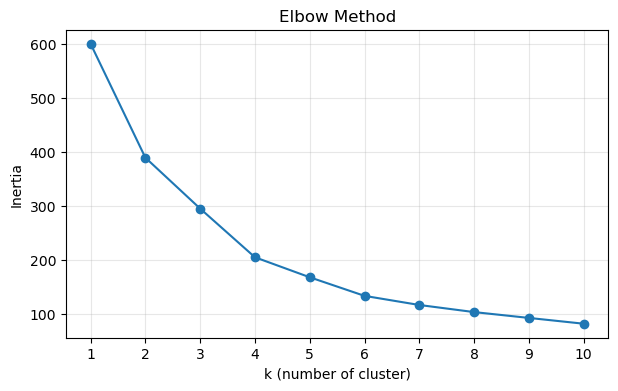

In [36]:
inertias =[]
k_range = range(1,11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(x)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("k (number of cluster)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(list(k_range))
plt.grid(alpha=0.3)
plt.show()

Inertia drops sharply from k=1 to roughly k=6, then the improvement rate flattens out. The elbow method suggest that k =6 is a reasonable choice, further than that the the splitting does not reveal any new structure.

### Silhoutte Score

In [37]:
candidate_k = [5,6]
sil_score = {}

for k in candidate_k:
    km= KMeans(n_clusters=k, random_state=42, n_init=10).fit(x)
    labels = km.labels_
    score = silhouette_score(x, labels)
    sil_score[k] = score
    print(f"k={k}: silhouette score = {score:.3f}")

best_k = max(sil_score, key=sil_score.get)
print(f"\nBest k by silhouette score: {best_k}")

k=5: silhouette score = 0.417
k=6: silhouette score = 0.428

Best k by silhouette score: 6


    Comparing candidate values, k = 5 scored 0.417 and k = 6 scored 0.428. k = 6  gave the highest silhouette score meaning points are generally better matched to their clusteres and clearly seperated from the nearest neighbouring cluster at k = 6 than k = 5. This confirms the Elbow method's estimate.

### Final K-Means and 2D Scatter plot

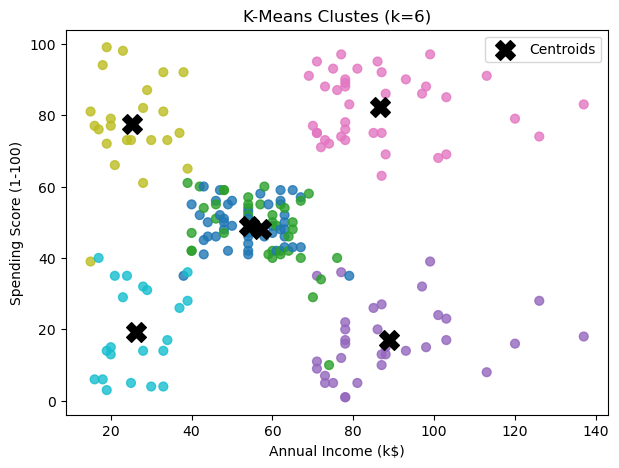

,Age,Annual Income (k$),Spending Score (1-100)
0,56.333333,54.266667,49.066667
1,26.794872,57.102564,48.128205
2,41.939394,88.939394,16.969697
3,32.692308,86.538462,82.128205
4,25.000000,25.260870,77.608696
5,45.523810,26.285714,19.380952


In [38]:
final_km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster"] = final_km.fit_predict(x)

centroids_og = scaler.inverse_transform(final_km.cluster_centers_)

plt.figure(figsize=(7,5))
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], c=df["cluster"], cmap="tab10", s=40, alpha=0.8)
plt.scatter(centroids_og[:, 1], centroids_og[:, 2], c="black", marker="X", s=200, label="Centroids")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title(f"K-Means Clustes (k={best_k})")
plt.legend()
plt.show()

pd.DataFrame(centroids_og, columns=["Age", "Annual Income (k$)", "Spending Score (1-100)"])

    The final model (k = 6) seperates customers along three axes - Age, Annual Income and Spending Score, but the scatter plot only visualizes two of them - income vs. Spending since a 3D relationship is hard to visualize on a flat chart.

    Clusters 0 and 1 land almost on the same income/spending plot but age seperates them in reality.
    Clusters 2 and 5  are clearly seperated by annual income while sharing a similar age and spending score ranges.
    Clusters 3 and 4 are mostly seperated by age and annual income.
    
    